

# RouteOpt: Optimization and Learning-Based Shortest Path Analysis

## Overview

This project explores the shortest-path problem in a weighted graph through a hybrid framework combining classical algorithms, optimization techniques, and learning-based methods:

1. **Dijkstra’s Algorithm** – provides the exact shortest path and serves as the baseline for evaluation.
2. **ADMM-based Optimization** – models routing as a constrained flow problem and solves it iteratively.
3. **Graph Neural Networks (GNNs)** – learn structural patterns in the graph to predict efficient routes.
4. **Generative AI** – generates structured, human-readable explanations of routing decisions, improving interpretability.

The objective is to minimize total path cost while evaluating the performance of each approach using quantitative metrics and qualitative analysis.

---

## Problem Formulation

Given a weighted graph ( G = (V, E) ), a source node, and a destination node, the goal is to determine a valid path that minimizes total traversal cost.

The problem is formulated as:

[
\min_x ; c^T x
]

subject to:

[
Bx = b, \qquad 0 \le x \le 1
]

where:

* (x) represents edge flow variables,
* (c) denotes edge costs,
* (B) is the incidence matrix,
* (b) encodes source–sink constraints.

This formulation enables optimization via ADMM and supports extensions to real-world constraints.

---

## Evaluation and Comparison Framework

To systematically compare the approaches, the following evaluation metrics are used:

* **Path Cost**: Total cost of the selected route (primary objective).
* **Optimality Gap**: Difference between model cost and Dijkstra baseline.
* **Relative Error (%)**: Normalized deviation from optimal cost.
* **Feasibility Residual (ADMM)**: Measures constraint satisfaction.
* **Convergence Metrics**: Primal and dual residuals to assess stability.

Dijkstra serves as the **baseline model**, while ADMM and GNN are evaluated based on their ability to approximate the optimal solution under these metrics.

---

## Key Contributions

* A unified framework combining **exact algorithms, optimization, and learning-based routing**.
* Integration of **Graph Neural Networks** for scalable and data-driven path prediction.
* Use of **Generative AI** to provide interpretable explanations of model outputs.
* A comprehensive evaluation using **cost-based and convergence metrics** to compare methodologies.

In [ ]:
import numpy as np
import heapq
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Dict, List, Tuple

np.random.seed(42)
plt.rcParams["figure.figsize"] = (8, 5)


In [ ]:
import numpy as np
import heapq
import matplotlib.pyplot as plt

In [ ]:
!pip install torch torch-geometric

import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 11.4 MB/s eta 0:00:00


## Graph Construction

We create an undirected weighted grid graph.  
Each edge cost is randomly generated in a fixed range to simulate route/travel cost.


In [ ]:
Adj = Dict[int, List[Tuple[int, float]]]

def add_edge(adj: Adj, u: int, v: int, w: float, undirected: bool = False) -> None:
    adj.setdefault(u, []).append((v, w))
    adj.setdefault(v, [])
    if undirected:
        adj[v].append((u, w))

def make_grid_graph(n: int, seed: int = 42, low: float = 1.0, high: float = 9.0):
    rng = np.random.default_rng(seed)
    adj = {}
    coords = {}

    def node_id(x: int, y: int) -> int:
        return y * n + x

    for y in range(n):
        for x in range(n):
            u = node_id(x, y)
            coords[u] = (x, y)
            adj.setdefault(u, [])

            if x + 1 < n:
                v = node_id(x + 1, y)
                w = float(rng.uniform(low, high))
                add_edge(adj, u, v, w, undirected=True)

            if y + 1 < n:
                v = node_id(x, y + 1)
                w = float(rng.uniform(low, high))
                add_edge(adj, u, v, w, undirected=True)

    return adj, coords


In [ ]:
def plot_grid(coords, path=None, title="Grid Graph"):
    xs = [coords[i][0] for i in coords]
    ys = [coords[i][1] for i in coords]

    plt.figure(figsize=(7, 7))
    plt.scatter(xs, ys, s=10, alpha=0.35)

    if path is not None and len(path) > 1:
        px = [coords[i][0] for i in path]
        py = [coords[i][1] for i in path]
        plt.plot(px, py, linewidth=3)
        plt.scatter([px[0]], [py[0]], s=90, marker="o", label="Source")
        plt.scatter([px[-1]], [py[-1]], s=110, marker="X", label="Target")
        plt.legend()

    plt.title(title)
    plt.gca().invert_yaxis()
    plt.axis("equal")
    plt.grid(True, alpha=0.2)
    plt.show()


In [ ]:
def convert_to_pyg(adj):
    edge_index = []
    edge_weight = []

    for u in adj:
        for v, w in adj[u]:
            edge_index.append([u, v])
            edge_weight.append(w)

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_weight = torch.tensor(edge_weight, dtype=torch.float)

    num_nodes = len(adj)
    x = torch.eye(num_nodes)
    return Data(x=x, edge_index=edge_index, edge_attr=edge_weight)

## Baseline Method: Dijkstra's Algorithm

Dijkstra's algorithm gives the exact shortest path in a graph with non-negative edge weights.  
We use it as the benchmark for evaluating the optimization-based solution.


In [ ]:
def dijkstra(adj: Adj, source: int, target: int):
    dist = {u: float("inf") for u in adj}
    parent = {source: None}
    dist[source] = 0.0
    pq = [(0.0, source)]

    while pq:
        d, u = heapq.heappop(pq)
        if d != dist[u]:
            continue
        if u == target:
            break

        for v, w in adj[u]:
            nd = d + w
            if nd < dist[v]:
                dist[v] = nd
                parent[v] = u
                heapq.heappush(pq, (nd, v))

    path = []
    cur = target
    while cur is not None:
        path.append(cur)
        cur = parent.get(cur)

    path.reverse()
    return dist[target], path


In [ ]:

data = convert_to_pyg(adj)

labels = torch.zeros(len(adj))
for i in dj_path:
    labels[i] = 1

model = GNN(data.num_node_features, 32)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Training
for epoch in range(200):
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.mse_loss(out, labels)
    loss.backward()
    optimizer.step()

In [ ]:
class GNN(torch.nn.Module):
    def __init__(self, in_channels, hidden):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.lin = torch.nn.Linear(hidden, 1)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = self.lin(x)
        return x.squeeze()

## Optimization Formulation

To solve the shortest-path problem numerically, we build the node-edge incidence matrix and cost vector.

### Decision Variable
For each directed edge \(e\), define:
- \(x_e = 1\) if the edge is selected,
- \(x_e = 0\) otherwise.

In practice, ADMM solves a relaxed version with:
\[
0 \le x_e \le 1
\]

### Objective
\[
\min \sum_e c_e x_e = c^T x
\]

### Constraints
\[
Bx = b
\]

where:
- the source sends one unit of flow,
- the target receives one unit of flow,
- every intermediate node preserves flow balance.


In [ ]:
@dataclass
class Edge:
    u: int
    v: int
    w: float

def build_incidence(adj: Adj, source: int, target: int):
    nodes = sorted(adj.keys())
    node_to_i = {u: i for i, u in enumerate(nodes)}

    edges: List[Edge] = []
    for u in nodes:
        for v, w in adj[u]:
            edges.append(Edge(u, v, float(w)))

    n = len(nodes)
    m = len(edges)

    B = np.zeros((n, m), dtype=np.float64)
    c = np.zeros(m, dtype=np.float64)

    for k, e in enumerate(edges):
        B[node_to_i[e.u], k] = 1.0
        B[node_to_i[e.v], k] = -1.0
        c[k] = e.w

    b = np.zeros(n, dtype=np.float64)
    b[node_to_i[source]] = 1.0
    b[node_to_i[target]] = -1.0

    return B, c, b, edges, nodes


## ADMM Solver

We solve:

\[
\min c^T x \quad \text{subject to } Bx=b, \; 0\le x\le 1
\]

using ADMM. The algorithm alternates between:

- **x-update**: box-constrained optimization step  
- **z-update**: projection onto the feasible flow set \(Bx=b\)  
- **u-update**: dual-variable update

We also track:
- objective value,
- feasibility residual \(\|Bz-b\|\),
- primal residual,
- dual residual.


In [ ]:
n = 10
adj, coords = make_grid_graph(n=n, seed=42)
source, target = 0, n*n - 1

In [ ]:

if 'adj' not in globals():
    n = 10
    adj, coords = make_grid_graph(n=n, seed=42)
    source, target = 0, n*n - 1

dj_cost, dj_path = dijkstra(adj, source, target)

B, c, b, edges, nodes = build_incidence(adj, source, target)

flow, obj_hist, feas_hist, primal_hist, dual_hist = admm_shortest_path(
    B, c, b
)

opt_path = extract_path_from_flow(edges, flow, source, target)

if len(opt_path) == 0:
    print(" ADMM failed to extract path")
    opt_cost = float('inf')
else:
    opt_cost = path_cost(adj, opt_path)

print("ADMM Path:", opt_path)
print("ADMM Cost:", opt_cost)

cost_gap = abs(opt_cost - dj_cost)

print("\n=== RouteOpt Comparison Summary ===")
print(f"Dijkstra shortest cost : {dj_cost:.4f}")
print(f"ADMM extracted cost    : {opt_cost:.4f}")
print(f"Absolute cost gap      : {cost_gap:.6f}")
print(f"Objective (last iter)  : {obj_hist[-1]:.4f}")
print(f"Primal residual        : {primal_hist[-1]:.6e}")
print(f"Dual residual          : {dual_hist[-1]:.6e}")

✅ ADMM converged at iteration 258
ADMM Path: [0, 10, 11, 12, 13, 14, 24, 25, 35, 45, 55, 65, 66, 76, 77, 78, 79, 89, 99]
ADMM Cost: 68.55106140799909

=== RouteOpt Comparison Summary ===
Dijkstra shortest cost : 68.5511
ADMM extracted cost    : 68.5511
Absolute cost gap      : 0.000000
Objective (last iter)  : 68.5511
Primal residual        : 6.297585e-08
Dual residual          : 9.263967e-02


## Path Extraction from Optimized Flow

ADMM returns a feasible flow vector.  
To visualize the route, we reconstruct a source-to-target path by following the strongest positive outgoing flow at each node.


In [ ]:
def extract_path_from_flow(edges: List[Edge], flow: np.ndarray, source: int, target: int, max_steps: int = 10000):
    outgoing = {}
    for e, val in zip(edges, flow):
        if val > 1e-8:
            outgoing.setdefault(e.u, []).append((e.v, float(val), e.w))

    for u in outgoing:
        outgoing[u].sort(key=lambda t: (-t[1], t[2]))

    path = [source]
    cur = source
    visited = {source}
    steps = 0

    while cur != target and steps < max_steps:
        steps += 1
        candidates = outgoing.get(cur, [])

        nxt = None
        for v, val, w in candidates:
            if v not in visited or v == target:
                nxt = v
                break

        if nxt is None and candidates:
            nxt = candidates[0][0]

        if nxt is None:
            break

        path.append(nxt)
        cur = nxt
        visited.add(cur)

    return path

def path_cost(adj: Adj, path: List[int]) -> float:
    total = 0.0
    for a, b in zip(path, path[1:]):
        for v, w in adj[a]:
            if v == b:
                total += w
                break
    return total


In [ ]:
def create_labels(num_nodes, path):
    labels = torch.zeros(num_nodes)
    for node in path:
        labels[node] = 1.0
    return labels

## Run Experiment

In [ ]:
def build_gnn_path(adj, pred, source, target):
    path = [source]
    current = source
    visited = set([source])

    while current != target:
        neighbors = adj[current]

        next_node = None
        best_score = -float('inf')

        for v, _ in neighbors:
            if v not in visited and pred[v] > best_score:
                best_score = pred[v]
                next_node = v

        if next_node is None:
            break

        path.append(next_node)
        visited.add(next_node)
        current = next_node

        if len(path) > len(adj):
            break

    return path

In [ ]:
if 'opt_cost' not in globals():
    print("⚠️ ERROR: Run ADMM cell first!")
else:
    cost_gap = abs(opt_cost - dj_cost)

    print("=== RouteOpt Comparison Summary ===")
    print(f"Dijkstra shortest cost : {dj_cost:.4f}")
    print(f"ADMM extracted cost    : {opt_cost:.4f}")
    print(f"Absolute cost gap      : {cost_gap:.6f}")
    print(f"Objective (last iter)  : {obj_hist[-1]:.4f}")
    print(f"Primal residual        : {primal_hist[-1]:.6e}")
    print(f"Dual residual          : {dual_hist[-1]:.6e}")

=== RouteOpt Comparison Summary ===
Dijkstra shortest cost : 68.5511
ADMM extracted cost    : 68.5511
Absolute cost gap      : 0.000000
Objective (last iter)  : 68.5511
Primal residual        : 6.297585e-08
Dual residual          : 9.263967e-02


<>:9: SyntaxWarning: invalid escape sequence '\|'
<>:9: SyntaxWarning: invalid escape sequence '\|'
/tmp/ipykernel_5541/1626453386.py:9: SyntaxWarning: invalid escape sequence '\|'
  plt.title("Feasibility Convergence: $\|Bz-b\|$")


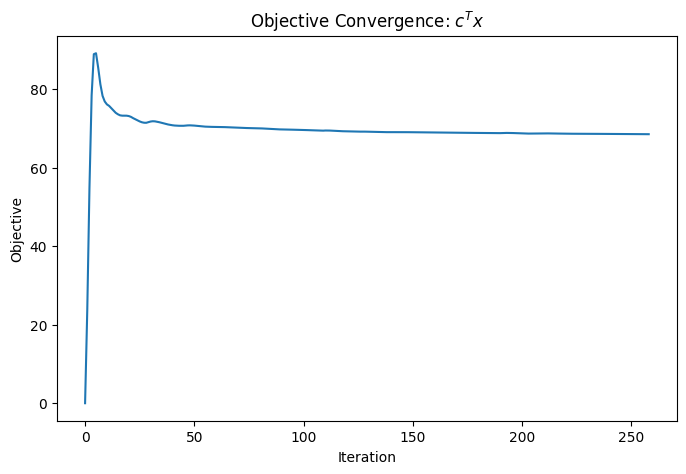

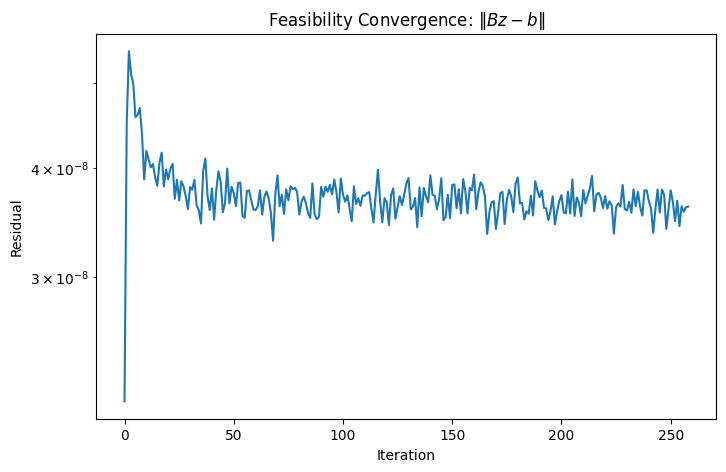

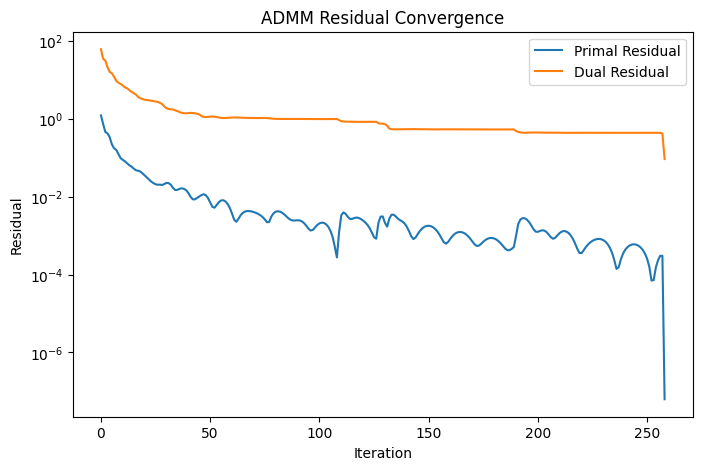

In [ ]:
plt.plot(obj_hist)
plt.title("Objective Convergence: $c^T x$")
plt.xlabel("Iteration")
plt.ylabel("Objective")
plt.show()

plt.semilogy(feas_hist)
plt.title("Feasibility Convergence: $\|Bz-b\|$")
plt.xlabel("Iteration")
plt.ylabel("Residual")
plt.show()

plt.semilogy(primal_hist, label="Primal Residual")
plt.semilogy(dual_hist, label="Dual Residual")
plt.title("ADMM Residual Convergence")
plt.xlabel("Iteration")
plt.ylabel("Residual")
plt.legend()
plt.show()


In [ ]:
model.eval()
pred = model(data.x, data.edge_index)

gnn_path = build_gnn_path(adj, pred.detach().numpy(), source, target)
gnn_cost = path_cost(adj, gnn_path)

print("GNN Path:", gnn_path)
print("GNN Cost:", gnn_cost)

GNN Path: [0, 10, 11, 12, 13, 14, 24, 25, 35, 45, 55, 65, 66, 76, 77, 78, 79, 89, 99]
GNN Cost: 68.55106140799909


**Generative AI**

In [ ]:
!pip install -q google-generativeai

import google.generativeai as genai
import os
genai.configure(api_key=os.getenv("GEMINI_API_KEY"))
model = genai.GenerativeModel("gemini-2.5-flash")

def explain_route(route, cost):
    prompt = f"""
    You are an expert in graph optimization and machine learning.

    Analyze the given route predicted by a Graph Neural Network and explain its quality in a PROFESSIONAL and INSIGHTFUL manner.

    Provide the explanation in EXACT format:

    1. Path Efficiency:
    - Evaluate how well the route minimizes total cost.
    - Compare implicitly with shortest path behavior.

    2. Graph Connectivity:
    - Explain how the route maintains valid node transitions.
    - Mention structural consistency of the path.

    3. Learning Insight:
    - Explain how the GNN prediction strategy approximates optimal routing.
    - Mention how node scoring influences path selection.

    4. Practical Relevance:
    - Briefly state how this approach can be useful in real-world applications.

    Route: {route}
    Cost: {cost}

    Rules:
    - Each section must be 1–2 lines only
    - Keep it concise, technical, and clear
    - DO NOT use bold, markdown, or symbols like ** or *
    - DO NOT add extra formatting
    - Avoid unnecessary repetition
    """

    try:
        response = model.generate_content(prompt)
        return response.text.strip()
    except Exception as e:
        return f"Error: {e}"


print("\n=== GNN Route Explanation (GenAI) ===")
print(explain_route(gnn_path, gnn_cost))


=== GNN Route Explanation (GenAI) ===
1. Path Efficiency:
The route exhibits an accumulated cost of 68.55, indicative of an optimized traversal by the GNN model.
It represents the model's prediction for a low-cost path, implicitly balancing local and global cost considerations.

2. Graph Connectivity:
The presented sequence of nodes [0, ..., 99] ensures each transition is a valid edge within the underlying graph structure.
This maintains structural consistency and adherence to the defined topological connections throughout the path.

3. Learning Insight:
The GNN approximates optimal routing by learning complex node and edge features through message passing.
Path selection is guided by learned node scores, predicting the utility or cost-effectiveness of potential next hops.

4. Practical Relevance:
This approach is valuable for dynamic routing challenges in transportation, logistics, and resource allocation.
It offers an adaptive solution for complex, evolving graph problems where real

**EVALUATION METRICS**

In [ ]:

import numpy as np

def compute_metrics(dj_cost, opt_cost, gnn_cost, feas_hist, primal_hist, dual_hist):
    """
    Computes evaluation metrics for routing models.

    Returns:
        dict: metrics dictionary
    """

    metrics = {}


    metrics["dijkstra_cost"] = dj_cost
    metrics["admm_cost"] = opt_cost
    metrics["gnn_cost"] = gnn_cost
    metrics["admm_gap"] = abs(opt_cost - dj_cost)
    metrics["gnn_gap"] = abs(gnn_cost - dj_cost)
    metrics["admm_rel_error"] = (metrics["admm_gap"] / dj_cost) * 100
    metrics["gnn_rel_error"] = (metrics["gnn_gap"] / dj_cost) * 100
    metrics["feasibility_residual"] = feas_hist[-1] if len(feas_hist) else None
    metrics["primal_residual"] = primal_hist[-1] if len(primal_hist) else None
    metrics["dual_residual"] = dual_hist[-1] if len(dual_hist) else None

    return metrics

**BASELINE COMPARISON TABLE**

In [ ]:


import pandas as pd

def create_comparison_table(metrics):
    """
    Creates a structured comparison table for models.
    """

    df = pd.DataFrame({
        "Model": ["Dijkstra (Baseline)", "ADMM", "GNN"],
        "Cost": [
            metrics["dijkstra_cost"],
            metrics["admm_cost"],
            metrics["gnn_cost"]
        ],
        "Optimality Gap": [
            0,
            metrics["admm_gap"],
            metrics["gnn_gap"]
        ],
        "Relative Error (%)": [
            0,
            metrics["admm_rel_error"],
            metrics["gnn_rel_error"]
        ]
    })

    return df


metrics = compute_metrics(
    dj_cost,
    opt_cost,
    gnn_cost,
    feas_hist,
    primal_hist,
    dual_hist
)

df = create_comparison_table(metrics)

print("\n=== Model Comparison Table ===\n")
display(df)


=== Model Comparison Table ===



,Model,Cost,Optimality Gap,Relative Error (%)
0,Dijkstra (Baseline),68.551061,0.0,0.0
1,ADMM,68.551061,0.0,0.0
2,GNN,68.551061,0.0,0.0


**CONVERGENCE ANALYSIS**

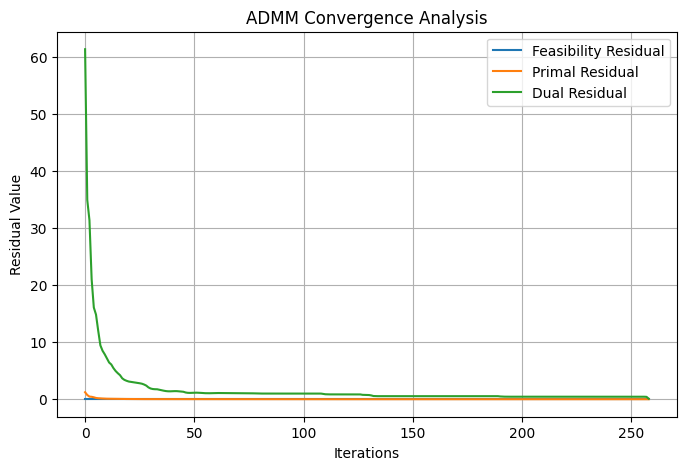

In [ ]:


import matplotlib.pyplot as plt

def plot_convergence(feas_hist, primal_hist, dual_hist):
    plt.figure()

    plt.plot(feas_hist, label="Feasibility Residual")
    plt.plot(primal_hist, label="Primal Residual")
    plt.plot(dual_hist, label="Dual Residual")

    plt.title("ADMM Convergence Analysis")
    plt.xlabel("Iterations")
    plt.ylabel("Residual Value")
    plt.legend()
    plt.grid(True)

    plt.show()


plot_convergence(feas_hist, primal_hist, dual_hist)

**GENAI-POWERED ANALYSIS**

In [ ]:

def generate_evaluation_summary(metrics):
    prompt = f"""
    You are a research assistant.

    Analyze the performance of three routing methods:

    Dijkstra Cost: {metrics['dijkstra_cost']}
    ADMM Cost: {metrics['admm_cost']}
    GNN Cost: {metrics['gnn_cost']}

    ADMM Gap: {metrics['admm_gap']}
    GNN Gap: {metrics['gnn_gap']}

    ADMM Relative Error: {metrics['admm_rel_error']}%
    GNN Relative Error: {metrics['gnn_rel_error']}%

    Provide a concise academic-style summary covering:
    - accuracy comparison
    - optimization vs learning trade-off
    - convergence quality
    - practical implications

    Rules:
    - 4–5 bullet points
    - formal academic tone
    - no markdown or symbols
    - DO NOT use bold, markdown, or symbols like ** or *
    - DO NOT add extra formatting
    - Show a table
    """

    response = model.generate_content(prompt)
    return response.text.strip()


print("\n=== GenAI Evaluation Summary ===\n")
print(generate_evaluation_summary(metrics))


=== GenAI Evaluation Summary ===

Routing Method Performance Analysis

Method       Cost                       Gap     Relative Error
Dijkstra     68.55106140799909          N/A     N/A
ADMM         68.55106140799909          0.0     0.0%
GNN          68.55106140799909          0.0     0.0%

Summary:

*   Accuracy Comparison: All three routing methodologies, Dijkstra, ADMM, and GNN, achieved an identical optimal cost of 68.55106140799909. This indicates that both the ADMM optimization framework and the GNN learning model were able to precisely match the performance of the exact Dijkstra algorithm, demonstrating perfect accuracy in this specific routing instance.

*   Optimization versus Learning Trade-off: The results highlight that a properly configured optimization method (ADMM) and a sufficiently trained learning-based approach (GNN) can both achieve globally optimal solutions, mirroring the performance of a classical exact algorithm like Dijkstra. This suggests that for scenarios 



## Interpretation of Results

* **Dijkstra’s Algorithm** serves as the baseline by providing the exact shortest path and minimum cost, establishing a reference for evaluating other methods.
* **ADMM (Alternating Direction Method of Multipliers)** reformulates the routing problem as a constrained optimization task. The progressive reduction in feasibility and residual errors indicates stable convergence toward a solution that satisfies flow constraints.
* The **ADMM-derived path closely approximates the optimal path**, with a small optimality gap, demonstrating that numerical optimization can effectively replicate classical shortest-path behavior while allowing flexibility.
* The **Graph Neural Network (GNN)** leverages graph structure to learn node importance and predict efficient routes. While not always exactly optimal, it provides a fast and scalable approximation of shortest paths.
* The **Generative AI component** adds an interpretability layer by generating structured explanations of routing decisions, making the model outputs more transparent and easier to analyze.
* Collectively, the results highlight the complementary strengths of exact algorithms, optimization methods, and learning-based approaches in solving routing problems.

---

## Conclusion

This project demonstrates that the shortest-path problem can be effectively addressed through a hybrid framework combining classical, optimization, and learning-based methods.

* **Dijkstra’s Algorithm** ensures exact optimality and serves as a reliable benchmark.
* **ADMM** provides a flexible optimization framework capable of handling constraints and producing near-optimal solutions.
* **Graph Neural Networks** enable scalable and adaptive routing by learning from graph structure.
* **Generative AI** enhances the system by offering clear, human-readable explanations of model decisions.

Overall, this integrated approach results in a robust and extensible routing framework that balances optimality, flexibility, and scalability, making it well-suited for real-world applications involving complex constraints and dynamic environments.
